In [1]:
import torch
from torch import nn
import transformers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
!pip install --upgrade datasets

In [2]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200

# 情感分析案例

In [3]:
from datasets import load_dataset

In [4]:
emotions = load_dataset('dair-ai/emotion')

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [5]:
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [6]:
emotions.keys()

dict_keys(['train', 'validation', 'test'])

In [7]:
print(emotions['train'],type(emotions['train']))
print(emotions['train']['text'][:5])
print(emotions['train']['label'][:5])

print(emotions['train'][:5])

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
}) <class 'datasets.arrow_dataset.Dataset'>
['i didnt feel humiliated', 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'im grabbing a minute to post i feel greedy wrong', 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property', 'i am feeling grouchy']
[0, 0, 3, 2, 3]
{'text': ['i didnt feel humiliated', 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'im grabbing a minute to post i feel greedy wrong', 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property', 'i am feeling grouchy'], 'label': [0, 0, 3, 2, 3]}


In [8]:
print(emotions['train'].features)
print(emotions['train'].features['label'])
print(emotions['train'].features['label'].int2str(2))

{'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}
ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])
love


In [9]:
labels = emotions['train'].features['label'].names
print(labels)
num_classes = len(labels)
num_classes

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


6

In [10]:
def int2str(x):
  return labels[x]

In [11]:
print(int2str(3))

anger


# 数据可视化分析

In [12]:
emotions_df = pd.DataFrame.from_dict(emotions['train'])

In [13]:
print(emotions_df.shape,emotions_df.columns)
emotions_df[:5]

(16000, 2) Index(['text', 'label'], dtype='object')


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [14]:
emotions_df['label_name'] = emotions_df['label'].apply(lambda x: labels[x])

In [15]:
emotions_df[:5]

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [16]:
emotions_df.label.value_counts()

,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


In [17]:
emotions_df.label_name.value_counts()

,count
label_name,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


Text(0.5, 1.0, 'freq of labels')

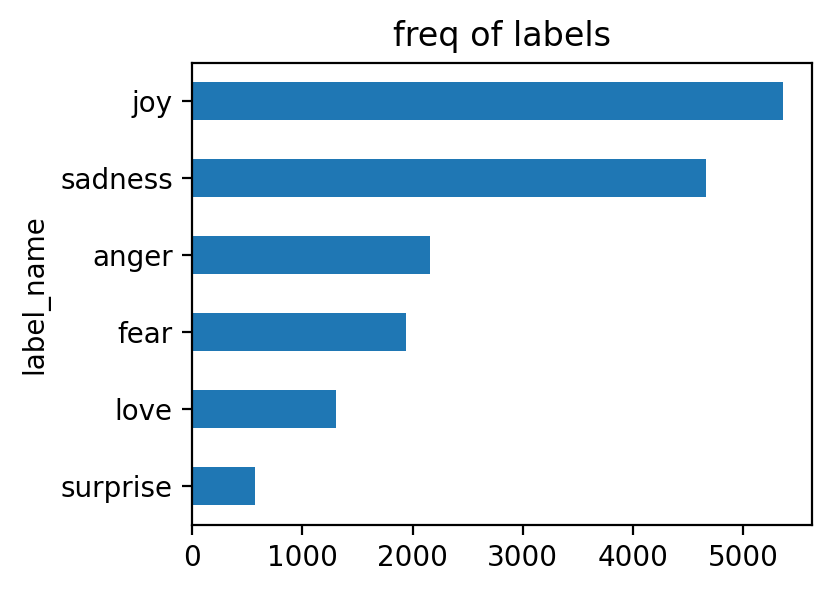

In [18]:
plt.figure(figsize=(4,3))
emotions_df['label_name'].value_counts(ascending=True).plot.barh()
plt.title('freq of labels')

Text(0.5, 0, '')

<Figure size 800x600 with 0 Axes>

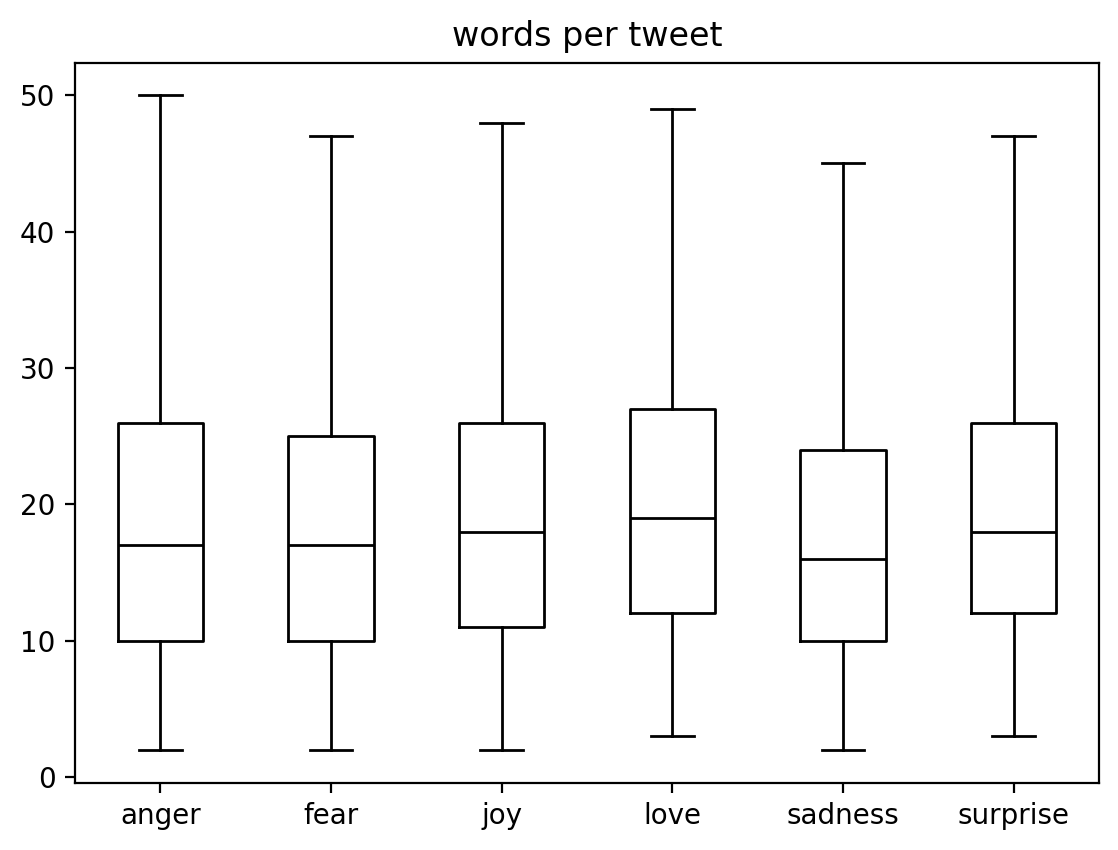

In [19]:
plt.figure(figsize=(4,3))
emotions_df['words per tweet'] = emotions_df['text'].str.split().apply(len)
emotions_df.boxplot('words per tweet',by='label_name',showfliers=False,grid=False,color='black')
plt.suptitle('')
plt.xlabel('')

In [20]:
print(emotions_df['words per tweet'].max())
print(emotions_df['words per tweet'].idxmax())

66
6322


In [21]:
print(emotions_df.iloc[6322])
emotions_df.iloc[6322]['text']

text               i guess which meant or so i assume no photos n...
label                                                              0
label_name                                                   sadness
words per tweet                                                   66
Name: 6322, dtype: object


'i guess which meant or so i assume no photos no words or no other way to convey what it really feels unless you feels it yourself or khi bi t au th m i bi t th ng ng i b au i rephrase it to a bit more gloomy context unless you are hurt yourself you will never have sympathy for the hurt ones'

In [22]:
print(emotions_df['words per tweet'].min())
print(emotions_df['words per tweet'].idxmin())

2
4150


In [23]:
emotions_df.iloc[4150]

,4150
text,earth crake
label,4
label_name,fear
words per tweet,2


# text测试完毕，转化为token

In [24]:
from transformers import AutoTokenizer

In [25]:
model_ckpt = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [26]:
print(tokenizer.encode('hello world'))
print(tokenizer.encode('HELLO WORLD'))
print(tokenizer.encode('Hello World'))

[101, 7592, 2088, 102]
[101, 7592, 2088, 102]
[101, 7592, 2088, 102]


In [27]:
tokenizer.encode(emotions_df.iloc[6332]['text'])

[101,
 10047,
 3110,
 11480,
 2035,
 10047,
 2428,
 2667,
 2000,
 2079,
 2003,
 2622,
 1996,
 6635,
 4500,
 102]

In [28]:
print(tokenizer.vocab_size)
print(tokenizer.model_max_length)
print(tokenizer.model_input_names)

30522
512
['input_ids', 'token_type_ids', 'attention_mask']


In [29]:
for special_id in tokenizer.all_special_ids:
  print(special_id,tokenizer.decode(special_id))

100 [UNK]
102 [SEP]
0 [PAD]
101 [CLS]
103 [MASK]


# 整个数据集tokenizer

In [30]:
def batch_tokenize(batch):
  return tokenizer(batch['text'],padding=True,truncation=True)

In [31]:
emotions_encoded = emotions.map(batch_tokenize,batched=True,batch_size=None)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [32]:
emotions_encoded

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [33]:
print(type(emotions_encoded['train']['input_ids']))

<class 'datasets.arrow_dataset.Column'>


In [34]:
emotions_encoded.set_format('torch',columns=['label','input_ids','attention_mask'])

In [35]:
type(emotions_encoded['train']['input_ids'])

datasets.arrow_dataset.Column

In [36]:
print(type(emotions_encoded['train'][0]['input_ids']))

<class 'torch.Tensor'>


In [37]:
emotions_encoded['train']['input_ids'][:3]

tensor([[  101,  1045,  2134,  2102,  2514, 26608,   102,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0],
        [  101,  1045,  2064,  2175,  2013,  3110,  2061, 20625,  2000,  2061,
          9636, 17772,  2074,  2013,  2108,  2105,  2619,  2040, 14977,  1998,
          2003,  8300,   102,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0, 

# fine-tune transformers

In [38]:
from transformers import AutoModel
model = AutoModel.from_pretrained(model_ckpt)
model

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [39]:
from transformers import AutoModelForSequenceClassification
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt,num_labels=num_classes)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [40]:
model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


# trainer

In [41]:
from huggingface_hub import notebook_login
notebook_login()

In [42]:
from transformers import TrainingArguments,Trainer

In [43]:
batch_size = 64
logging_steps = len(emotions_encoded['train']) // batch_size
model_name = f'{model_ckpt}_emotion_ft_0416'
training_args = TrainingArguments(output_dir=model_name,
                                  num_train_epochs=4,
                                  learning_rate=2e-5,
                                  per_device_train_batch_size=batch_size,
                                  per_device_eval_batch_size=batch_size,
                                  weight_decay=0.01,
                                  eval_strategy="epoch",
                                  disable_tqdm=False,
                                  logging_steps=logging_steps,
                                  # write
                                  push_to_hub=True,
                                  log_level="error")

* trainer默认自动开启 torch 的多gpu模式,
  * `per_device_train_batch_size`: 这里是设置每个gpu上的样本数量,
  * 一般来说，多gpu模式希望多个gpu的性能尽量接近，否则最终多gpu的速度由最慢的gpu决定，
    * 比如快gpu 跑一个batch需要5秒，跑10个batch 50秒，慢的gpu跑一个batch 500秒，则快gpu还要等慢gpu跑完一个batch然后一起更新weights，速度反而更慢了。
  * 同理 `per_device_eval_batch_size` 类似
* `learning_rate` / `weight_decay`
  * 默认使用AdamW的优化算法

In [44]:
# import importlib
# importlib.reload(py_file)
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# for classification
def plot_confusion_matrix(y_preds, y_true, labels):
    cm = confusion_matrix(y_true, y_preds, normalize="true")
    fig, ax = plt.subplots(figsize=(4, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
    plt.title("Normalized confusion matrix")

# trainable parameters of the model
def get_params(model):
    model_parameters = filter(lambda p: p.requires_grad, model.parameters())
    params = sum([np.prod(p.size()) for p in model_parameters])
    return params

def compute_classification_metrics(pred):
    # pred: PredictionOutput
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, average='macro')
    return {"accuracy": acc, "f1": f1, 'precision': precision}

In [45]:
trainer = Trainer(model=model,
                  processing_class=tokenizer,
                  train_dataset=emotions_encoded['train'],
                  eval_dataset=emotions_encoded['validation'],
                  args=training_args,
                  compute_metrics=compute_classification_metrics)

In [46]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision
1,0.760989,0.265346,0.919500,0.919696,0.885813
2,0.206808,0.183302,0.927000,0.926964,0.901465
3,0.139159,0.162017,0.934500,0.935032,0.900278
4,0.110310,0.151428,0.934500,0.934403,0.911912


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1000, training_loss=0.3043165626525879, metrics={'train_runtime': 494.5785, 'train_samples_per_second': 129.403, 'train_steps_per_second': 2.022, 'total_flos': 1440685723392000.0, 'train_loss': 0.3043165626525879, 'epoch': 4.0})

In [47]:
preds_output = trainer.predict(emotions_encoded['validation'])
preds_output

PredictionOutput(predictions=array([[ 5.730216  , -0.8548421 , -1.419426  , -0.9607663 , -1.0495325 ,
        -1.8381711 ],
       [ 5.7287483 , -0.7842862 , -1.7022628 , -0.8840066 , -0.9304092 ,
        -1.8234288 ],
       [-1.383836  ,  3.2772155 ,  3.7703264 , -1.2765218 , -2.1467106 ,
        -2.0551307 ],
       ...,
       [-1.3393867 ,  5.8966694 , -0.2677027 , -1.3438756 , -1.9848822 ,
        -1.6797572 ],
       [-1.9100311 ,  4.188031  ,  3.01514   , -1.6027218 , -2.138403  ,
        -1.7501429 ],
       [-1.531166  ,  5.767841  , -0.34851265, -1.575824  , -1.8050966 ,
        -1.1386665 ]], dtype=float32), label_ids=array([0, 0, 2, ..., 1, 1, 1]), metrics={'test_loss': 0.15142828226089478, 'test_accuracy': 0.9345, 'test_f1': 0.9344031057690954, 'test_precision': 0.9119120056659901, 'test_runtime': 3.9284, 'test_samples_per_second': 509.109, 'test_steps_per_second': 8.146})

In [48]:
preds_output = trainer.predict(emotions_encoded['validation'])
y_preds = np.argmax(preds_output.predictions,axis=-1)

In [50]:
y_true = emotions_encoded['validation']['label']

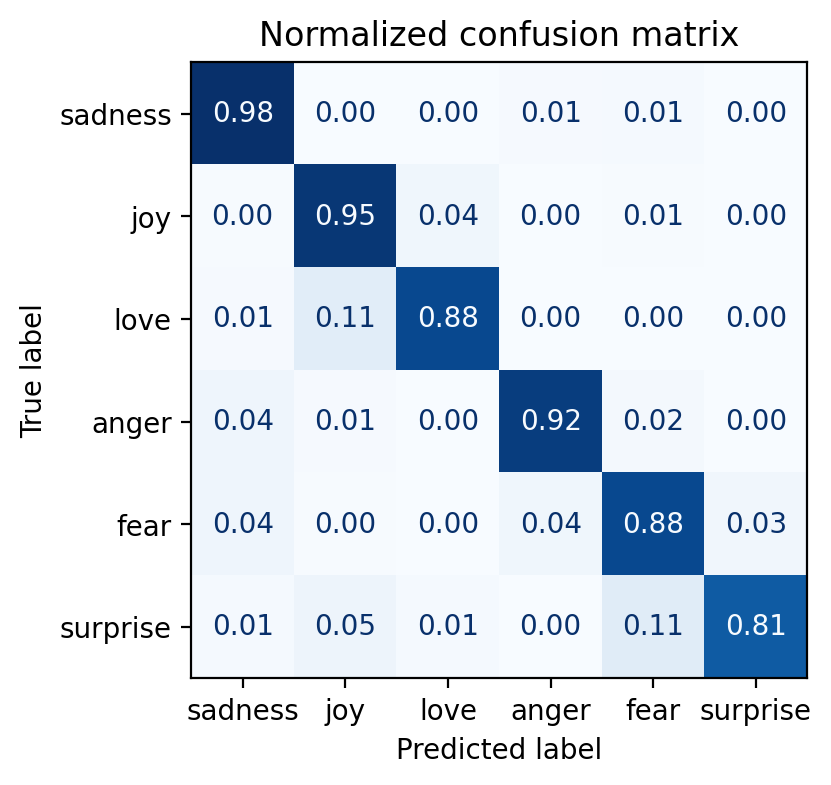

In [52]:
plot_confusion_matrix(y_preds,y_true,labels)

# result analysis

In [53]:
from torch.nn.functional import cross_entropy

In [54]:
def forward_pass_with_label(batch):
    # Place all input tensors on the same device as the model
    inputs = {k:v.to(device) for k,v in batch.items()
              if k in tokenizer.model_input_names}

    with torch.no_grad():
        output = model(**inputs)
        pred_label = torch.argmax(output.logits, axis=-1)
        loss = cross_entropy(output.logits, batch["label"].to(device),
                             reduction="none")

    # Place outputs on CPU for compatibility with other dataset columns
    return {"loss": loss.cpu().numpy(),
            "predicted_label": pred_label.cpu().numpy()}

In [55]:
emotions_encoded['validation'] = emotions_encoded['validation'].map(
    forward_pass_with_label,batched=True,batch_size=16
)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

NameError: name 'device' is not defined